In [12]:
fifa_matches = [
    # match_id, stage, home, away, ht_home, ht_away, ft_home, ft_away
    (1,  "Group A",       "Mexico",   "South Africa", 1, 0, 2, 0),
    (2,  "Group A",       "Czechia",  "South Africa", 1, 0, 1, 1),
    (3,  "Group B",       "Switzerland", "Qatar", 1, 0, 1, 1),
    (4,  "Group B",       "Bosnia and Herzegovina", "Qatar", 2, 1, 3, 1),
    (5,  "Group C",       "Brazil",   "Morocco", 1, 1, 1, 1),
    (6,  "Group D",       "USA",      "Australia", 2, 0, 2, 0),
    (7,  "Group D",       "Paraguay", "Turkey", 1, 0, 1, 0),
    (8,  "Group E",       "Germany",  "Curacao", 3, 1, 7, 1),
    (9,  "Group G",       "Belgium",  "Iran", 0, 0, 0, 0),
    (10, "Group H",       "Spain",    "Saudi Arabia", 3, 0, 4, 0),
    (11, "Group H",       "Cape Verde", "Saudi Arabia", 0, 0, 0, 0),
    (12, "Round of 16",   "England",  "DR Congo", 0, 1, 2, 1),
    (13, "Round of 16",   "Portugal", "Spain", 0, 0, 0, 1),
]

In [13]:
columns = [
    "match_id",
    "stage",
    "home_team",
    "away_team",
    "ht_home_goals",
    "ht_away_goals",
    "ft_home_goals",
    "ft_away_goals"
]

In [14]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import random

In [15]:
df = pd.DataFrame(fifa_matches, columns=columns)

# 1st half and 2nd half total goals
df["first_half_goals"]  = df["ht_home_goals"] + df["ht_away_goals"]
df["full_time_goals"]   = df["ft_home_goals"] + df["ft_away_goals"]
df["second_half_goals"] = df["full_time_goals"] - df["first_half_goals"]
df["goal_diff_2h_minus_1h"] = df["second_half_goals"] - df["first_half_goals"]
df["match_label"] = df["home_team"] + " vs " + df["away_team"] + " (" + df["stage"] + ")"

# sanity checks
assert (df["second_half_goals"] >= 0).all(), "Negative second-half goals detected!"
assert (df["full_time_goals"] == (df["ft_home_goals"]+df["ft_away_goals"])).all()

df_out = df[["match_id","match_label","stage","home_team","away_team",
             "ht_home_goals","ht_away_goals","ft_home_goals","ft_away_goals",
             "first_half_goals","second_half_goals","goal_diff_2h_minus_1h"]]
print("Cleaned dataset (n = {}):".format(len(df_out)))
print(df_out[["match_label","first_half_goals","second_half_goals"]].to_string(index=False))

Cleaned dataset (n = 13):
                              match_label  first_half_goals  second_half_goals
         Mexico vs South Africa (Group A)                 1                  1
        Czechia vs South Africa (Group A)                 1                  1
           Switzerland vs Qatar (Group B)                 1                  1
Bosnia and Herzegovina vs Qatar (Group B)                 3                  1
              Brazil vs Morocco (Group C)                 2                  0
               USA vs Australia (Group D)                 2                  0
             Paraguay vs Turkey (Group D)                 1                  0
             Germany vs Curacao (Group E)                 4                  4
                Belgium vs Iran (Group G)                 0                  0
          Spain vs Saudi Arabia (Group H)                 3                  1
     Cape Verde vs Saudi Arabia (Group H)                 0                  0
        England vs DR Cong

In [16]:
# Data Sample
n = len(df_out)

print(f"\nSAMPLING\nMatches analysed: {n}\nPopulation: 104 matches from the 2026 FIFA World Cup.\nSampling method: Purposive/availability sampling. Matches were selected based on the availability of reliable half-time and full-time score information. Therefore, the sample is not randomly selected from the full population, which is a limitation of the analysis.")


SAMPLING
Matches analysed: 13
Population: 104 matches from the 2026 FIFA World Cup.
Sampling method: Purposive/availability sampling. Matches were selected based on the availability of reliable half-time and full-time score information. Therefore, the sample is not randomly selected from the full population, which is a limitation of the analysis.


In [17]:
# Descriptive statistics
fh = df_out["first_half_goals"].to_numpy(dtype=float)
sh = df_out["second_half_goals"].to_numpy(dtype=float)
d  = sh - fh   # difference, second half minus first half (paired)

def describe(x, label):
    return {
        "label": label,
        "n": len(x),
        "mean": np.mean(x),
        "median": np.median(x),
        "std": np.std(x, ddof=1),
        "sem": stats.sem(x),
        "min": np.min(x),
        "max": np.max(x),
        "var": np.var(x, ddof=1),
    }

desc_fh = describe(fh, "First-half goals per match")
desc_sh = describe(sh, "Second-half goals per match")
desc_d  = describe(d,  "Difference (2nd half - 1st half)")

desc_df = pd.DataFrame([desc_fh, desc_sh, desc_d]).set_index("label")
print("\nDESCRIPTIVE STATISTICS")
print(desc_df.round(3).to_string())


DESCRIPTIVE STATISTICS
                                   n   mean  median    std    sem  min  max    var
label                                                                             
First-half goals per match        13  1.462     1.0  1.266  0.351  0.0  4.0  1.603
Second-half goals per match       13  0.923     1.0  1.115  0.309  0.0  4.0  1.244
Difference (2nd half - 1st half)  13 -0.538     0.0  1.127  0.312 -2.0  1.0  1.269


In [18]:
total_goals = df_out["first_half_goals"].sum() + df_out["second_half_goals"].sum()
pct_fh = 100 * df_out["first_half_goals"].sum() / total_goals
pct_sh = 100 * df_out["second_half_goals"].sum() / total_goals
print(f"\nShare of total goals scored in 1st half: {pct_fh:.1f}%")
print(f"Share of total goals scored in 2nd half: {pct_sh:.1f}%")


Share of total goals scored in 1st half: 61.3%
Share of total goals scored in 2nd half: 38.7%


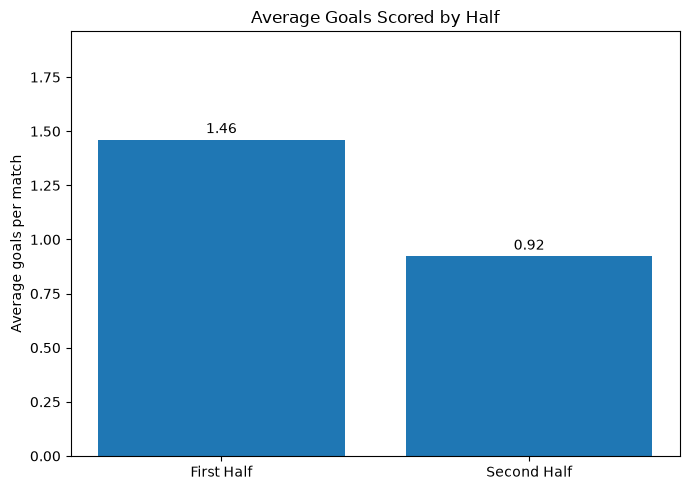

In [19]:
plt.figure(figsize=(7, 5))

half_means = [
    df_out["first_half_goals"].mean(),
    df_out["second_half_goals"].mean()
]

plt.bar(["First Half", "Second Half"], half_means)

plt.ylabel("Average goals per match")
plt.title("Average Goals Scored by Half")
plt.ylim(0, max(half_means) + 0.5)

for i, value in enumerate(half_means):
    plt.text(i, value + 0.03, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.show()

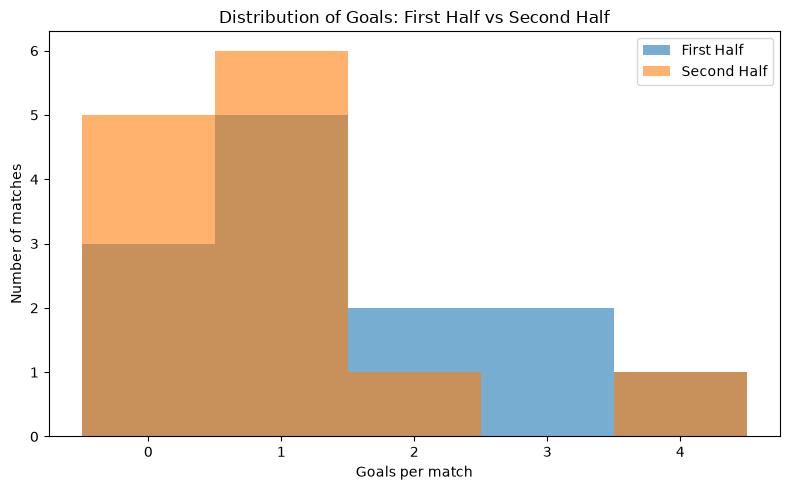

In [20]:
plt.figure(figsize=(8, 5))

bins = np.arange(-0.5, max(
    df_out["first_half_goals"].max(),
    df_out["second_half_goals"].max()
) + 1.5, 1)

plt.hist(
    df_out["first_half_goals"],
    bins=bins,
    alpha=0.6,
    label="First Half"
)

plt.hist(
    df_out["second_half_goals"],
    bins=bins,
    alpha=0.6,
    label="Second Half"
)

plt.xlabel("Goals per match")
plt.ylabel("Number of matches")
plt.title("Distribution of Goals: First Half vs Second Half")
plt.xticks(range(
    int(max(df_out["first_half_goals"].max(),
            df_out["second_half_goals"].max())) + 1
))
plt.legend()

plt.tight_layout()
plt.show()

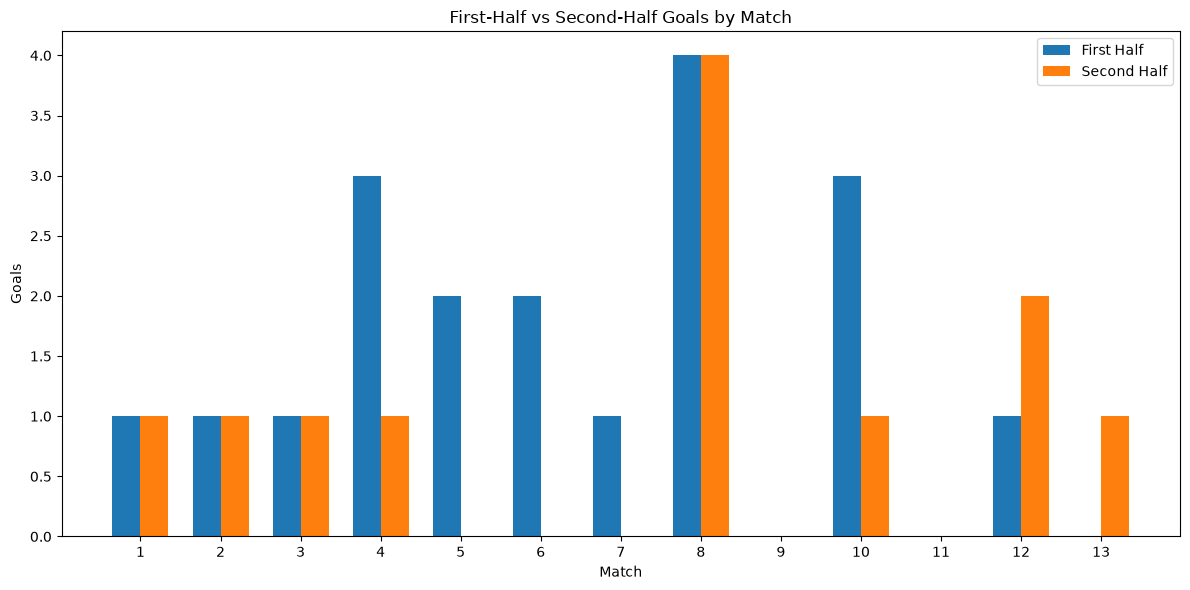

In [21]:

plt.figure(figsize=(12, 6))

x = np.arange(len(df_out))
width = 0.35

plt.bar(
    x - width/2,
    df_out["first_half_goals"],
    width,
    label="First Half"
)

plt.bar(
    x + width/2,
    df_out["second_half_goals"],
    width,
    label="Second Half"
)

plt.xlabel("Match")
plt.ylabel("Goals")
plt.title("First-Half vs Second-Half Goals by Match")

plt.xticks(
    x,
    df_out["match_id"]
)

plt.legend()
plt.tight_layout()

plt.show()

In [22]:
# Confidence interval
def ci_mean(x, conf=0.95):
    m = np.mean(x)
    se = stats.sem(x)
    dfree = len(x) - 1
    tcrit = stats.t.ppf((1 + conf) / 2, dfree)
    return m, m - tcrit * se, m + tcrit * se, tcrit, se

m_fh, lo_fh, hi_fh, t_fh, se_fh = ci_mean(fh)
m_sh, lo_sh, hi_sh, t_sh, se_sh = ci_mean(sh)
m_d,  lo_d,  hi_d,  t_d,  se_d  = ci_mean(d)

print("\n95% CONFIDENCE INTERVALS")
print(f"First half  mean = {m_fh:.3f}, 95% CI = [{lo_fh:.3f}, {hi_fh:.3f}]")
print(f"Second half mean = {m_sh:.3f}, 95% CI = [{lo_sh:.3f}, {hi_sh:.3f}]")
print(f"Mean difference (2nd-1st) = {m_d:.3f}, 95% CI = [{lo_d:.3f}, {hi_d:.3f}]")


95% CONFIDENCE INTERVALS
First half  mean = 1.462, 95% CI = [0.697, 2.227]
Second half mean = 0.923, 95% CI = [0.249, 1.597]
Mean difference (2nd-1st) = -0.538, 95% CI = [-1.219, 0.142]


In [23]:
# T Test
t_stat, p_value = stats.ttest_1samp(d, popmean=0)
dof = n - 1
cohens_d = m_d / desc_d["std"]

print("\n PAIRED (ONE-SAMPLE) T-TEST ON DIFFERENCES")
print(f"H0: mean difference = 0   |   H1: mean difference != 0")
print(f"n = {n}, df = {dof}")
print(f"t-statistic = {t_stat:.4f}")
print(f"p-value (two-tailed) = {p_value:.4f}")
print(f"Cohen's d (paired) = {cohens_d:.3f}")
alpha = 0.05
sig = "REJECT H0 (statistically significant)" if p_value < alpha else "FAIL TO REJECT H0 (not statistically significant)"
print(f"Decision at alpha=0.05: {sig}")

t_stat_ind, p_value_ind = stats.ttest_ind(fh, sh, equal_var=False)
print("\nSUPPLEMENTARY: INDEPENDENT TWO-SAMPLE (WELCH) T-TEST")
print(f"t-statistic = {t_stat_ind:.4f}, p-value = {p_value_ind:.4f}")


 PAIRED (ONE-SAMPLE) T-TEST ON DIFFERENCES
H0: mean difference = 0   |   H1: mean difference != 0
n = 13, df = 12
t-statistic = -1.7233
p-value (two-tailed) = 0.1105
Cohen's d (paired) = -0.478
Decision at alpha=0.05: FAIL TO REJECT H0 (not statistically significant)

SUPPLEMENTARY: INDEPENDENT TWO-SAMPLE (WELCH) T-TEST
t-statistic = 1.1508, p-value = 0.2613


In [24]:
# Result display
results = {
    "Sample size": n,
    "First-half mean": m_fh,
    "First-half SD": desc_fh["std"],
    "First-half 95% CI": f"[{lo_fh:.3f}, {hi_fh:.3f}]",
    "Second-half mean": m_sh,
    "Second-half SD": desc_sh["std"],
    "Second-half 95% CI": f"[{lo_sh:.3f}, {hi_sh:.3f}]",
    "Mean difference (2H - 1H)": m_d,
    "Difference 95% CI": f"[{lo_d:.3f}, {hi_d:.3f}]",
    "t-statistic": t_stat,
    "Degrees of freedom": dof,
    "p-value": p_value,
    "Cohen's d": cohens_d,
    "First-half goal share (%)": pct_fh,
    "Second-half goal share (%)": pct_sh
}

results_df = pd.DataFrame(
    results.items(),
    columns=["Measure", "Result"]
)

display(results_df)

,Measure,Result
0,Sample size,13
1,First-half mean,1.461538
2,First-half SD,1.265924
3,First-half 95% CI,"[0.697, 2.227]"
4,Second-half mean,0.923077
5,Second-half SD,1.115164
6,Second-half 95% CI,"[0.249, 1.597]"
7,Mean difference (2H - 1H),-0.538462
8,Difference 95% CI,"[-1.219, 0.142]"
9,t-statistic,-1.723281
